In [1]:
import pandas as pd

df = pd.read_stata("AERtables1-5.dta")
df.head()


,amount,freq,HPA,ask1,ask2,ask3,control,treatment,ask,ratio,...,size25,size50,size100,MRM2,dormant,ltmedMRA,red0,blue0,close25,amountchange
0,0.0,32.0,500.0,750.0,950.0,1125.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,19.0,1.0,0.0,1.0,0.0,0.0,-150.0
1,0.0,22.0,300.0,500.0,625.0,750.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,29.0,1.0,0.0,1.0,0.0,0.0,-100.0
2,0.0,22.0,500.0,750.0,950.0,1125.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,-218.0
3,0.0,29.0,250.0,500.0,625.0,750.0,0.0,1.0,3.0,3.0,...,0.0,1.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0,-50.0
4,0.0,17.0,50.0,55.0,70.0,85.0,0.0,1.0,3.0,2.0,...,0.0,0.0,0.0,8.0,1.0,0.0,0.0,1.0,0.0,-50.0


In [2]:
df.columns


Index(['amount', 'freq', 'HPA', 'ask1', 'ask2', 'ask3', 'control', 'treatment',
       'ask', 'ratio', 'size', 'gave', 'sizeno', 'years', 'couple', 'female',
       'redcty', 'bluecty', 'askd1', 'askd2', 'askd3', 'cases', 'nonlit',
       'ratio2', 'ratio3', 'size25', 'size50', 'size100', 'MRM2', 'dormant',
       'ltmedMRA', 'red0', 'blue0', 'close25', 'amountchange'],
      dtype='object')

In [3]:
# 1. response rate
df.groupby("treatment")["gave"].mean()


treatment
0.0    0.017858
1.0    0.022039
Name: gave, dtype: float32

In [4]:
# 2. 平均捐款（包括没捐的人）
df.groupby("treatment")["amount"].mean()


treatment
0.0    0.813268
1.0    0.966873
Name: amount, dtype: float32

In [5]:
# 3. 只看捐款的人（conditional）
df[df["gave"] == 1].groupby("treatment")["amount"].mean()


treatment
0.0    45.540268
1.0    43.871876
Name: amount, dtype: float32

In [6]:
import statsmodels.formula.api as smf

# 是否捐款
model1 = smf.ols("gave ~ treatment", data=df).fit()
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:                   gave   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     9.618
Date:                Wed, 22 Apr 2026   Prob (F-statistic):            0.00193
Time:                        20:55:59   Log-Likelihood:                 26630.
No. Observations:               50083   AIC:                        -5.326e+04
Df Residuals:                   50081   BIC:                        -5.324e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0179      0.001     16.225      0.0

In [7]:
# 捐款金额
model2 = smf.ols("amount ~ treatment", data=df).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                 amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.461
Date:                Wed, 22 Apr 2026   Prob (F-statistic):             0.0628
Time:                        20:56:07   Log-Likelihood:            -1.7946e+05
No. Observations:               50083   AIC:                         3.589e+05
Df Residuals:                   50081   BIC:                         3.589e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8133      0.067     12.063      0.0

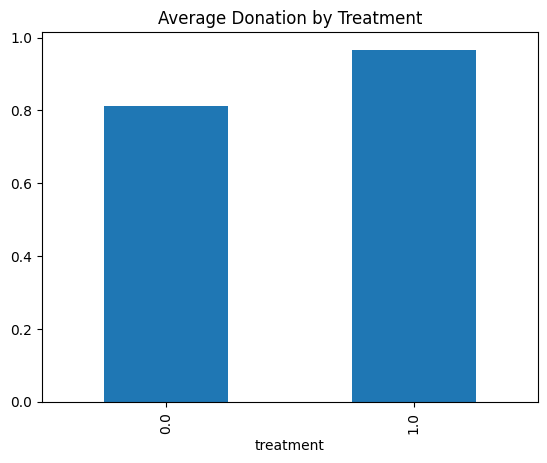

In [8]:
import matplotlib.pyplot as plt

df.groupby("treatment")["amount"].mean().plot(kind="bar")
plt.title("Average Donation by Treatment")
plt.show()
